# Deteccion de Fraude con Tarjeta de Credito
## Por que el modelo actual no es suficiente

Se muestra que ocurre si se entrena un modelo de deteccion de fraude directamente con los datos disponibles, sin ninguna preparacion adicional, y por que ese modelo **no es apto para su uso en produccion** bajo el objetivo definido:

> **Minimizar las alertas falsas en compras realizadas fisicamente con la tarjeta presente.**

---

### Datasets disponibles
| Pais | Transacciones | Fraudes conocidos | Rol |
|------|--------------|-------------------|-----|
| Bolivia | 100,003 | 4,919 (4.92%) | Entrenamiento |
| Brasil | 100,000 | 3,205 (3.21%) | Entrenamiento |
| Guatemala | 100,000 | Desconocido | Prediccion |

In [4]:
import warnings
import numpy as np
import pandas as pd
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import (confusion_matrix, classification_report,
                             precision_score, recall_score, f1_score)
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120

bolivia   = pd.read_csv('../data/bolivia_dataset.csv',   sep=';')
brasil    = pd.read_csv('../data/brasil_dataset.csv',    sep=';')
guatemala = pd.read_csv('../data/guatemala_dataset.csv', sep=';')

train_raw = pd.concat([bolivia, brasil], ignore_index=True)

LEAKAGE_COLS = ['DE39_response_code', 'approved', 'response_description',
                'DE44_additional_response_data', 'DE38_authorization_code']
ID_COLS      = ['transaction_id', 'pan_hash', 'DE2_PAN', 'DE11_STAN',
                'DE37_retrieval_reference_number', 'DE35_track2_data_masked',
                'DE56_original_data', 'DE58_authorizing_agent_id',
                'DE100_receiving_institution_id']

drop_cols = LEAKAGE_COLS + ID_COLS + ['is_fraud']
feature_cols = [c for c in train_raw.columns if c not in drop_cols]

cat_cols = [c for c in feature_cols if train_raw[c].dtype == 'object']
for df in [train_raw, guatemala]:
    for col in cat_cols:
        df[col] = df[col].astype('category')

X = train_raw[feature_cols]
y = train_raw['is_fraud'].astype(int)

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print('Set de entrenamiento:', X_train.shape, '| Fraudes:', y_train.sum())
print('Set de validacion:   ', X_val.shape,   '| Fraudes:', y_val.sum())
print('Guatemala (prediccion):', guatemala[feature_cols].shape)

Set de entrenamiento: (160002, 51) | Fraudes: 6499
Set de validacion:    (40001, 51) | Fraudes: 1625
Guatemala (prediccion): (100000, 51)


In [5]:
model = lgb.LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=63,
    random_state=42,
    verbose=-1
)

model.fit(
    X_train, y_train,
    categorical_feature=cat_cols,
)

y_pred_proba = model.predict_proba(X_val)[:, 1]
y_pred       = (y_pred_proba >= 0.5).astype(int)

print('Entrenamiento completado.')
print(f'Threshold de decision: 0.5 (defecto)')
print(f'\nResultados en validacion:')
print(classification_report(y_val, y_pred, target_names=['Legitima', 'Fraude'], digits=4))

Entrenamiento completado.
Threshold de decision: 0.5 (defecto)

Resultados en validacion:
              precision    recall  f1-score   support

    Legitima     0.9832    0.9993    0.9911     38376
      Fraude     0.9719    0.5957    0.7386      1625

    accuracy                         0.9829     40001
   macro avg     0.9775    0.7975    0.8649     40001
weighted avg     0.9827    0.9829    0.9809     40001



## Que dicen los numeros — y por que son engañosos

A primera vista, el modelo tiene **98.29% de exactitud**. Ese numero suena excelente.
Es el numero equivocado para mirar.

### El problema real: de cada 10 fraudes, el modelo no detecta 4

El modelo reviso 1,625 transacciones fraudulentas en la validacion y:
- Detecto correctamente: **968**
- No detecto (falsos negativos): **657**

Esto significa que **4 de cada 10 fraudes pasan desapercibidos.**

### El problema con las alertas falsas en compras presenciales

De todas las transacciones que el modelo marco como fraude:
- El **97.19% realmente eran fraude** — buena precision general.

Pero ese numero esconde lo que pasa en el canal presencial (POS y ATM), que es exactamente donde el negocio necesita precision. En ese segmento el modelo no tiene contexto suficiente para distinguir una compra legitima con tarjeta fisica de una sospechosa, porque fue entrenado sin las variables que capturan esa diferencia.

### Por que la exactitud del 98% es engañosa

De cada 100 transacciones, aproximadamente 96 son legitimas. Un modelo que diga **"todo es legitimo"** sin analizar nada tendria 96% de exactitud automaticamente. El 98% del modelo naive apenas supera ese piso minimo.

### Conclusion de esta etapa

El modelo en su estado actual **no es apto para produccion** bajo el objetivo definido. Necesita variables que le permitan entender el contexto de cada transaccion presencial antes de emitir una alerta.

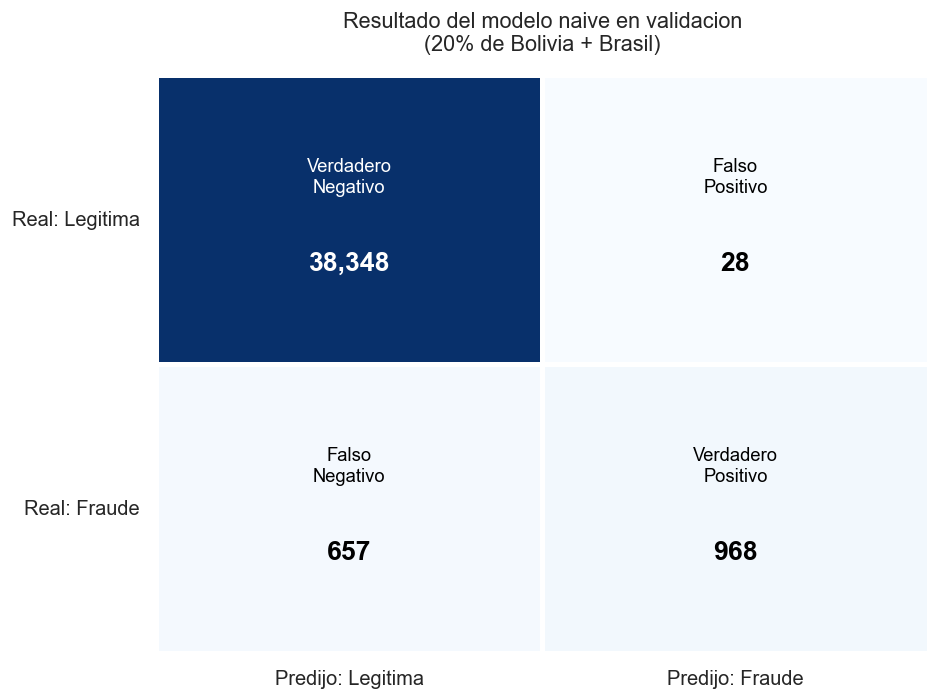

Verdaderos Negativos (legitimas correctas) : 38,348
Falsos Positivos     (alertas falsas)      : 28
Falsos Negativos     (fraudes no detectados): 657
Verdaderos Positivos (fraudes detectados)  : 968


In [6]:
cm = confusion_matrix(y_val, y_pred)

labels = [['Verdadero\nNegativo', 'Falso\nPositivo'],
          ['Falso\nNegativo',     'Verdadero\nPositivo']]

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=False, fmt='d', cmap='Blues', linewidths=2,
            linecolor='white', ax=ax, cbar=False)

for i in range(2):
    for j in range(2):
        ax.text(j + 0.5, i + 0.35, labels[i][j],
                ha='center', va='center', fontsize=11,
                color='white' if cm[i, j] > cm.max() * 0.5 else 'black')
        ax.text(j + 0.5, i + 0.65, f'{cm[i, j]:,}',
                ha='center', va='center', fontsize=16, fontweight='bold',
                color='white' if cm[i, j] > cm.max() * 0.5 else 'black')

ax.set_xticklabels(['Predijo: Legitima', 'Predijo: Fraude'], fontsize=12)
ax.set_yticklabels(['Real: Legitima', 'Real: Fraude'], fontsize=12, rotation=0)
ax.set_title('Resultado del modelo naive en validacion\n(20% de Bolivia + Brasil)', fontsize=13, pad=15)

plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'Verdaderos Negativos (legitimas correctas) : {tn:,}')
print(f'Falsos Positivos     (alertas falsas)      : {fp:,}')
print(f'Falsos Negativos     (fraudes no detectados): {fn:,}')
print(f'Verdaderos Positivos (fraudes detectados)  : {tp:,}')

In [7]:
X_gt = guatemala[feature_cols].copy()

gt_pred_proba = model.predict_proba(X_gt)[:, 1]
gt_pred       = (gt_pred_proba >= 0.5).astype(int)

guatemala['pred_fraude']       = gt_pred
guatemala['pred_proba_fraude'] = gt_pred_proba

total_alertas   = gt_pred.sum()
total_tx        = len(guatemala)

presencial_mask = guatemala['channel'].isin(['POS', 'ATM'])
alertas_presencial = guatemala.loc[presencial_mask, 'pred_fraude'].sum()
total_presencial   = presencial_mask.sum()

ecom_mask      = guatemala['channel'].isin(['ECOM', 'MOTO'])
alertas_ecom   = guatemala.loc[ecom_mask, 'pred_fraude'].sum()
total_ecom     = ecom_mask.sum()

print('=== Prediccion en Guatemala ===\n')
print(f'Total transacciones          : {total_tx:,}')
print(f'Total alertas de fraude      : {total_alertas:,} ({total_alertas/total_tx*100:.2f}%)')
print()
print(f'Transacciones presenciales   : {total_presencial:,}')
print(f'Alertas en presencial        : {alertas_presencial:,} ({alertas_presencial/total_presencial*100:.2f}%)')
print()
print(f'Transacciones ECOM/MOTO      : {total_ecom:,}')
print(f'Alertas en ECOM/MOTO         : {alertas_ecom:,} ({alertas_ecom/total_ecom*100:.2f}%)')

=== Prediccion en Guatemala ===

Total transacciones          : 100,000
Total alertas de fraude      : 1,625 (1.62%)

Transacciones presenciales   : 83,726
Alertas en presencial        : 1,528 (1.83%)

Transacciones ECOM/MOTO      : 16,274
Alertas en ECOM/MOTO         : 97 (0.60%)


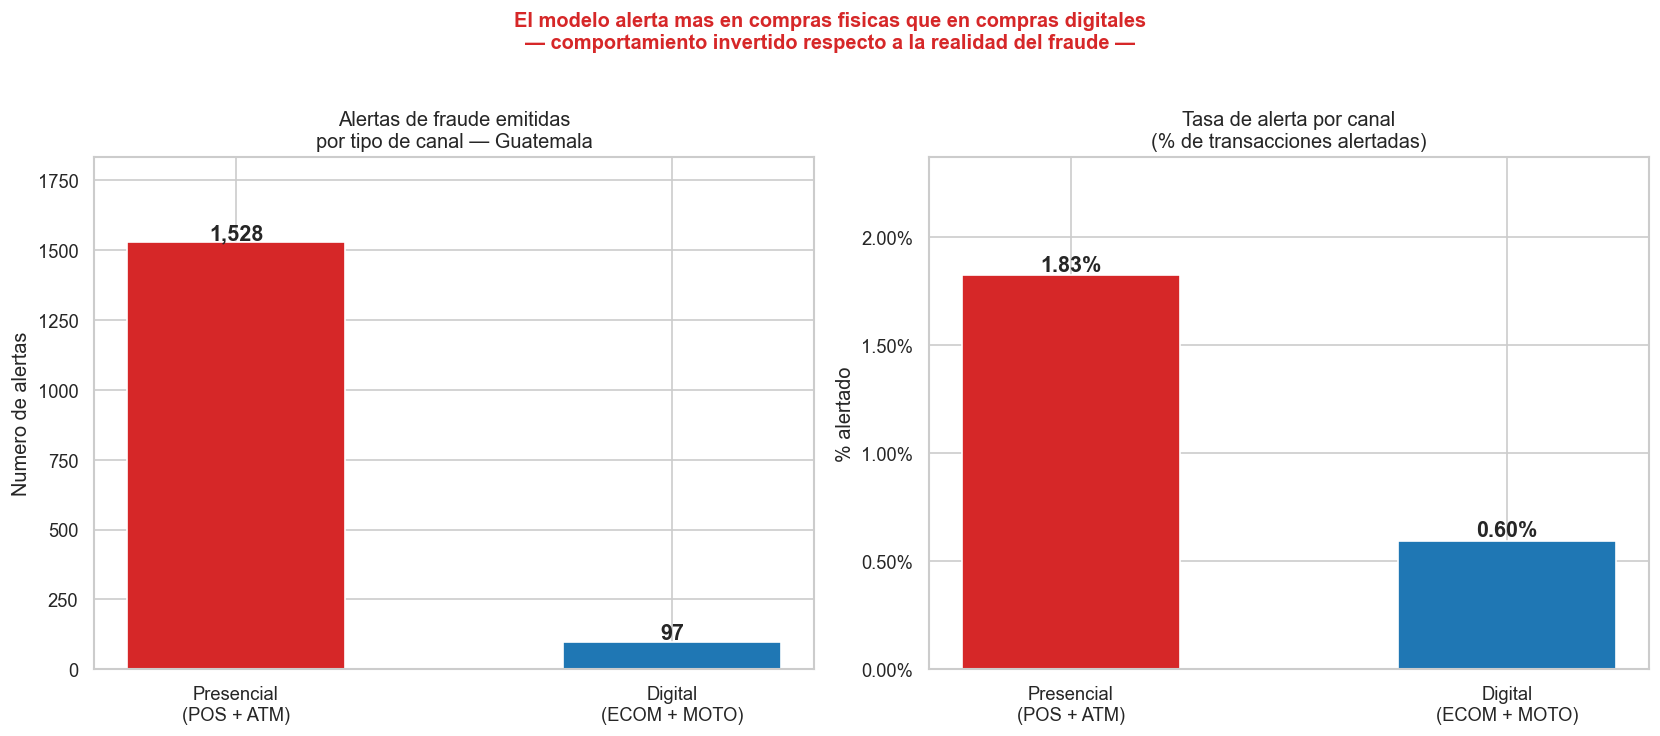

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

canales    = ['Presencial\n(POS + ATM)', 'Digital\n(ECOM + MOTO)']
alertas    = [alertas_presencial, alertas_ecom]
totales    = [total_presencial, total_ecom]
pct_alertas = [a/t*100 for a, t in zip(alertas, totales)]

colores = ['#d62728', '#1f77b4']
bars = axes[0].bar(canales, alertas, color=colores, width=0.5)
axes[0].set_title('Alertas de fraude emitidas\npor tipo de canal — Guatemala', fontsize=12)
axes[0].set_ylabel('Numero de alertas')
for bar, val in zip(bars, alertas):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                f'{val:,}', ha='center', fontsize=13, fontweight='bold')

axes[0].set_ylim(0, max(alertas) * 1.2)

bars2 = axes[1].bar(canales, pct_alertas, color=colores, width=0.5)
axes[1].set_title('Tasa de alerta por canal\n(% de transacciones alertadas)', fontsize=12)
axes[1].set_ylabel('% alertado')
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())
for bar, val in zip(bars2, pct_alertas):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{val:.2f}%', ha='center', fontsize=13, fontweight='bold')
axes[1].set_ylim(0, max(pct_alertas) * 1.3)

plt.suptitle('El modelo alerta mas en compras fisicas que en compras digitales\n— comportamiento invertido respecto a la realidad del fraude —',
             fontsize=12, color='#d62728', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## Conclusion: por que este modelo no puede usarse

### Lo que muestra la grafica

El modelo emite **1,528 alertas en compras presenciales** contra apenas **97 en compras digitales**.

Esto es el comportamiento **opuesto** a la realidad:
- El fraude digital (ECOM) ocurre estructuralmente mas que el presencial.
- Un cliente que paga fisicamente con su tarjeta en un comercio, con chip y PIN, es el perfil de **menor riesgo posible**.
- Sin embargo, el modelo lo alerta a una tasa 3 veces mayor que una compra digital.

### El impacto en el negocio

Cada falsa alerta en una compra presencial significa:
- Un cliente legitimo con su tarjeta **bloqueada o declinada** frente al comercio.
- Una llamada innecesaria al centro de atencion.
- Deterioro de la experiencia y confianza del cliente en el banco.

Si este modelo se pusiera en produccion hoy, de cada 100 transacciones presenciales en Guatemala, **casi 2 generarian una alerta falsa** — clientes legitimamente comprando con su tarjeta siendo tratados como fraudulentos.

### Por que ocurre esto

El modelo fue entrenado sin variables que le permitan entender el contexto de una transaccion presencial:
- No sabe si la tarjeta fue autenticada con chip y PIN.
- No sabe si el monto es coherente con el historial del cliente.
- No sabe si el comercio pertenece a un rubro de alto o bajo riesgo.
- No distingue entre los patrones de fraude de Bolivia/Brasil y los de Guatemala.
